The samples with the computational negative peptides are structures 36389-36496

In [1]:
from pathlib import Path
import joblib
import json
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Dict, Any, Optional

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

def load_rf_ensemble(prefix: str):
    # load_rf_ensemble()
    prefix = Path(prefix)
    models = joblib.load(prefix.with_suffix(".joblib"))
    meta = json.loads(prefix.with_suffix(".meta.json").read_text())
    features = meta["features"]
    return models, features

@dataclass
class RFEnsembleResult:
    models: List[RandomForestClassifier]
    metrics: pd.DataFrame              # per-run metrics (auc, acc, seed, n_test_pos, n_test_neg)
    feature_importances: pd.DataFrame  # per-run importances (rows=runs, cols=features)
    mean_auc: float
    std_auc: float
    mean_acc: float
    std_acc: float
        
def predict_with_ensemble(
    ensemble: RFEnsembleResult,
    features,
    df_new,
    proba_agg="mean"
):
    X_new = df_new[features]

    # shape: (n_models, n_samples)
    probas = np.vstack([
        m.predict_proba(X_new)[:, 1]
        for m in ensemble[0]
    ])

    if proba_agg == "mean":
        p = probas.mean(axis=0)
    elif proba_agg == "median":
        p = np.median(probas, axis=0)
    else:
        raise ValueError("proba_agg must be 'mean' or 'median'")

    yhat = (p >= 0.5).astype(int)

    return p, yhat, probas


In [2]:
model = load_rf_ensemble(prefix = "dt_out/res_af2_v2_lowFNR")

In [3]:
# df = pd.read_csv("dt/HPV_epitope_binder_1_1000_results_pae.tsv", sep = "\t")
df = pd.read_csv("dt/restricted_motifs_results_combined_w_pae.tsv", sep = "\t")




In [4]:
df['id'] = df['sample_id'].apply(lambda x: x.split("_")[0])

In [5]:
df['c2t_binder'] = ~df['id'].astype(int).isin(range(36389,36496+1))

In [6]:
df['c2t_binder']

0         True
1         True
2         True
3         True
4         True
         ...  
36491    False
36492    False
36493    False
36494    False
36495    False
Name: c2t_binder, Length: 36496, dtype: bool

In [7]:
p, yhat, probas = predict_with_ensemble(ensemble = model, features = ["pmhc_tcr_pae", "model_2_ptm_ft4_plddt",'model_2_ptm_ft4_pae', 'model_2_ptm_ft4_plddt_0',
       'model_2_ptm_ft4_pae_0_0', 'model_2_ptm_ft4_pae_0_1',
       'model_2_ptm_ft4_pae_0_2', 'model_2_ptm_ft4_pae_0_3',
       'model_2_ptm_ft4_plddt_1', 'model_2_ptm_ft4_pae_1_0',
       'model_2_ptm_ft4_pae_1_1', 'model_2_ptm_ft4_pae_1_2',
       'model_2_ptm_ft4_pae_1_3', 'model_2_ptm_ft4_plddt_2',
       'model_2_ptm_ft4_pae_2_0', 'model_2_ptm_ft4_pae_2_1',
       'model_2_ptm_ft4_pae_2_2', 'model_2_ptm_ft4_pae_2_3',
       'model_2_ptm_ft4_plddt_3', 'model_2_ptm_ft4_pae_3_0',
       'model_2_ptm_ft4_pae_3_1', 'model_2_ptm_ft4_pae_3_2',
       'model_2_ptm_ft4_pae_3_3'], df_new = df)

In [8]:
df['prediction'] = p

In [9]:
df['prediction_yhat'] = yhat

In [10]:
np.sum(p)/len(p)

np.float64(0.2770948500758881)

In [11]:
np.sum(yhat)/len(yhat)

np.float64(0.1571679088119246)

In [12]:
np.sum(yhat)

np.int64(5736)

<Axes: xlabel='c2t_binder', ylabel='prediction'>

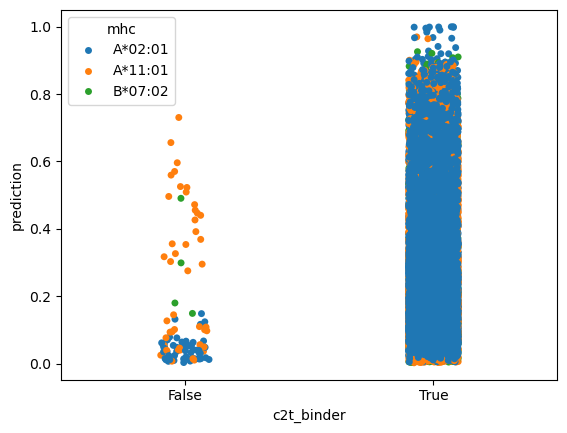

In [13]:
sns.stripplot(df, x = "c2t_binder", y = "prediction", hue = "mhc")

<Axes: xlabel='c2t_binder', ylabel='prediction'>

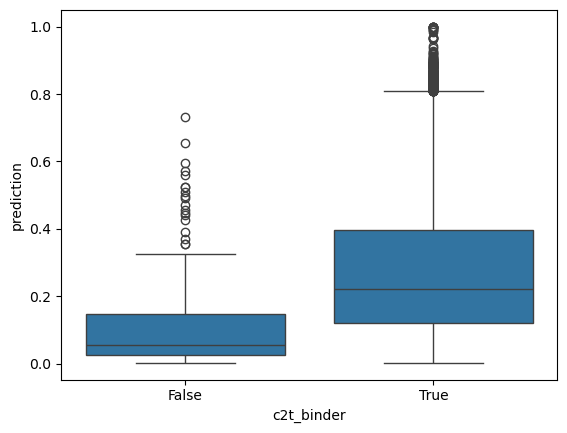

In [14]:
sns.boxplot(df, x = "c2t_binder", y = "prediction")

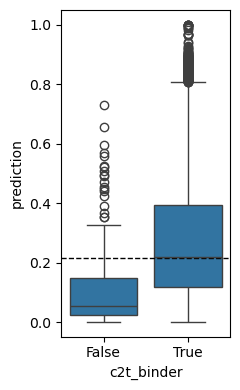

0.218

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use a fully editable vector font
plt.rcParams["pdf.fonttype"] = 42   # TrueType (editable)
plt.rcParams["ps.fonttype"] = 42

plt.figure(figsize=(2.5, 4))
sns.boxplot(data=df, x="c2t_binder", y="prediction")
plt.axhline(0.218, color="black", linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig("figures/boxplot_cell2tcr_prediction.pdf", format="pdf")
plt.show()
plt.close()
0.218

In [16]:
df.columns

Index(['sample_id', 'organism', 'mhc_class', 'mhc', 'peptide', 'va', 'ja',
       'cdr3a', 'vb', 'jb', 'cdr3b', 'mhc_peptide', 'targetid',
       'target_chainseq', 'templates_alignfile', 'model_2_ptm_ft4_plddt',
       'model_2_ptm_ft4_pae', 'model_2_ptm_ft4_plddt_0',
       'model_2_ptm_ft4_pae_0_0', 'model_2_ptm_ft4_pae_0_1',
       'model_2_ptm_ft4_pae_0_2', 'model_2_ptm_ft4_pae_0_3',
       'model_2_ptm_ft4_plddt_1', 'model_2_ptm_ft4_pae_1_0',
       'model_2_ptm_ft4_pae_1_1', 'model_2_ptm_ft4_pae_1_2',
       'model_2_ptm_ft4_pae_1_3', 'model_2_ptm_ft4_plddt_2',
       'model_2_ptm_ft4_pae_2_0', 'model_2_ptm_ft4_pae_2_1',
       'model_2_ptm_ft4_pae_2_2', 'model_2_ptm_ft4_pae_2_3',
       'model_2_ptm_ft4_plddt_3', 'model_2_ptm_ft4_pae_3_0',
       'model_2_ptm_ft4_pae_3_1', 'model_2_ptm_ft4_pae_3_2',
       'model_2_ptm_ft4_pae_3_3', 'model_name', 'pmhc_tcr_pae', 'id',
       'c2t_binder', 'prediction', 'prediction_yhat'],
      dtype='object')

Add additional metadata

In [29]:
df_meta = pd.read_csv("dt/tcr_pMHC_CMV_EBV_flu_restricted_motifs_sampled_2_nonBEAM_TCRs_per_motif.csv")

/tmp/ipykernel_1265624/2811250016.py:1: DtypeWarning: Columns (9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv("dt/tcr_pMHC_CMV_EBV_flu_restricted_motifs_sampled_2_nonBEAM_TCRs_per_motif.csv")


In [48]:
df_meta = df_meta[df_meta['sampled_2_nonBEAM_TCRs_per_motif'] == True]

In [49]:
df_meta['tpm_id'] = df_meta['vj_aa'] + "_" + df_meta['vdj_aa'] + "_" + df_meta['Peptide']

In [50]:
df['tpm_id'] = df['cdr3a'] + "_" + df['cdr3b'] + "_" + df['peptide']

In [51]:
len(df['tpm_id'].unique())

36496

In [52]:
len(df['tpm_id'])

36496

In [53]:
df = df.merge(df_meta, on = "tpm_id", how = "outer")

In [54]:
df.to_csv("dt_out/predictions/EBV_CMV_flue_restricted_motifs_results_combined_w_pae_wPredictions.csv",index = None)

ADD MORE METADATA

In [2]:
df = pd.read_csv("dt_out/predictions/EBV_CMV_flue_restricted_motifs_results_combined_w_pae_wPredictions.csv")

/tmp/ipykernel_3343946/3130843983.py:1: DtypeWarning: Columns (54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dt_out/predictions/EBV_CMV_flue_restricted_motifs_results_combined_w_pae_wPredictions.csv")


In [3]:
df_meta = pd.read_csv("dt/tcr_pMHC_CMV_EBV_flu_restricted_motifs_assignment.csv")

In [4]:
df_meta['motif_epitope'] = df_meta['motif'].astype(str) + "_" + df_meta['majority_beam_epitope'].astype(str)

In [5]:
df['motif_epitope'] = (
    df['motif'].fillna(0).astype(int).astype(str) + 
    "_" + 
    df['peptide'].astype(str)
)

In [6]:
len(df_meta['motif_epitope'])

27

In [7]:
df['in_beam'] = df['motif_epitope'].isin(df_meta['motif_epitope'])

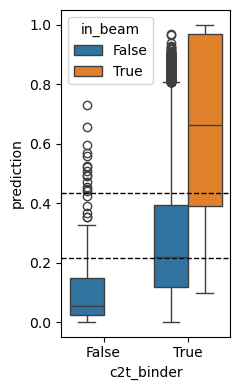

In [8]:
# Use a fully editable vector font
plt.rcParams["pdf.fonttype"] = 42   # TrueType (editable)
plt.rcParams["ps.fonttype"] = 42

plt.figure(figsize=(2.5, 4))
sns.boxplot(data=df, x="c2t_binder", y="prediction", hue = "in_beam")
plt.axhline(0.218, color="black", linestyle="--", linewidth=1)
plt.axhline(0.218*2, color="black", linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig("figures/boxplot_cell2tcr_prediction_splitInBEAM.pdf", format="pdf")
plt.show()
# plt.close()


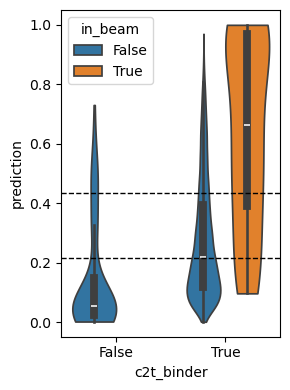

In [12]:
# Use a fully editable vector font
plt.rcParams["pdf.fonttype"] = 42   # TrueType (editable)
plt.rcParams["ps.fonttype"] = 42

plt.figure(figsize=(3, 4))
sns.violinplot(data=df, x="c2t_binder", y="prediction", hue = "in_beam", cut=0)
plt.axhline(0.218, color="black", linestyle="--", linewidth=1)
plt.axhline(0.218*2, color="black", linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig("figures/violinplot_cell2tcr_prediction_splitInBEAM.pdf", format="pdf")
plt.show()
# plt.close()


In [13]:
df_c2t = df[df['c2t_binder']]

In [37]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

group_a = df_c2t[df_c2t['in_beam'] == True]['prediction']
group_b = df_c2t[df_c2t['in_beam'] == False]['prediction']
stats, p1 = mannwhitneyu(group_a, group_b)

In [38]:
group_a = df_c2t[df_c2t['in_beam'] == True]['prediction']
group_b = df[df['c2t_binder'] == False]['prediction']
stats, p2 = mannwhitneyu(group_a, group_b)

In [39]:
group_a = df_c2t[df_c2t['in_beam'] == False]['prediction']
group_b = df[df['c2t_binder'] == False]['prediction']
stats, p3 = mannwhitneyu(group_a, group_b)

In [40]:
multipletests([p1,p2,p3], alpha=0.05, method='fdr_bh')

(array([ True,  True,  True]),
 array([3.76792429e-14, 1.02707659e-16, 9.70877593e-21]),
 np.float64(0.016952427508441503),
 0.016666666666666666)

In [42]:
from scipy import stats

df_c2t[df_c2t['in_beam'] == True]

stats.spearmanr(df_c2t[df_c2t['in_beam'] == True]['motif'], df_c2t[df_c2t['in_beam'] == True]['prediction'])

SignificanceResult(statistic=np.float64(-0.7542908401938673), pvalue=np.float64(5.998959919026418e-10))

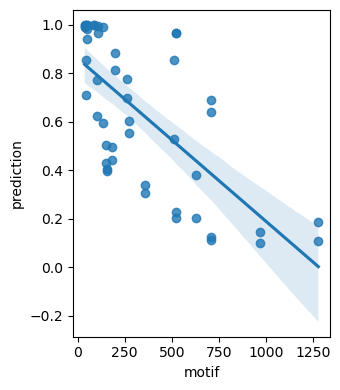

In [66]:
# Use a fully editable vector font
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

plt.figure(figsize=(3.5, 4))

# plt.axhline(0.218, color="black", linestyle="--", linewidth=1)
sns.regplot(data=df_c2t[df_c2t['in_beam'] == True], x="motif", y="prediction")

plt.tight_layout()

plt.savefig("figures/violinplot_cell2tcr_predictedBEAM_correlation_motif_prediction.pdf", format="pdf")

plt.show()
# plt.close()


<Axes: xlabel='in_beam', ylabel='model_2_ptm_ft4_plddt_3'>

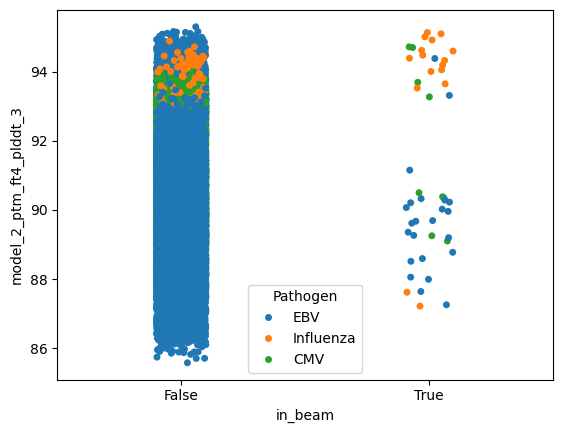

In [77]:
sns.stripplot(data=df, x="in_beam", y="model_2_ptm_ft4_plddt_3", hue = "Pathogen")

<Axes: xlabel='in_beam', ylabel='model_2_ptm_ft4_plddt_2'>

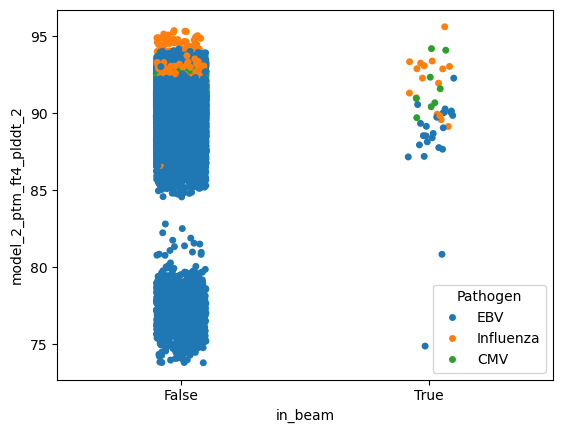

In [76]:
sns.stripplot(data=df, x="in_beam", y="model_2_ptm_ft4_plddt_2", hue = "Pathogen")

<Axes: xlabel='in_beam', ylabel='model_2_ptm_ft4_plddt_1'>

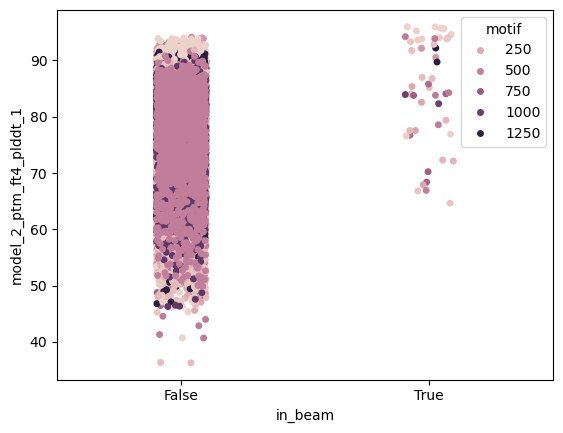

In [75]:
sns.stripplot(data=df, x="in_beam", y="model_2_ptm_ft4_plddt_1", hue = "motif")

In [52]:
!ls /rds/project/rds-C9woKbOCf2Y/mgi21/TCR-pMHC_Modelling/EBV_flu_restricted_motifs/EBV_flu_restricted_motifs_results/restricted_motifs_4001_5000_results/

prediction_final.tsv
prediction_T00000_A0201_HLFSSCLEVEL_0_model_1_model_2_ptm_ft4.pdb
prediction_T00000_A0201_HLFSSCLEVEL_0_model_1_model_2_ptm_ft4_plddt.npy
prediction_T00000_A0201_HLFSSCLEVEL_0_model_1_model_2_ptm_ft4_predicted_aligned_error.npy
prediction_T00000_A0201_HLFSSCLEVEL_0_model_1_model_2_ptm_ft4_ptm.npy
prediction_T00001_A0201_HLGPSLLSL_0_model_1_model_2_ptm_ft4.pdb
prediction_T00001_A0201_HLGPSLLSL_0_model_1_model_2_ptm_ft4_plddt.npy
prediction_T00001_A0201_HLGPSLLSL_0_model_1_model_2_ptm_ft4_predicted_aligned_error.npy
prediction_T00001_A0201_HLGPSLLSL_0_model_1_model_2_ptm_ft4_ptm.npy
prediction_T00002_A0201_HLHALTHSL_0_model_1_model_2_ptm_ft4.pdb
prediction_T00002_A0201_HLHALTHSL_0_model_1_model_2_ptm_ft4_plddt.npy
prediction_T00002_A0201_HLHALTHSL_0_model_1_model_2_ptm_ft4_predicted_aligned_error.npy
prediction_T00002_A0201_HLHALTHSL_0_model_1_model_2_ptm_ft4_ptm.npy
prediction_T00003_A0201_HLIREITPI_0_model_1_model_2_ptm_ft4.pdb
prediction_T00003_A0201_HLIREITPI_0_m

In [58]:
df[df['model_2_ptm_ft4_plddt'] == np.max(df['model_2_ptm_ft4_plddt'])]

,sample_id,organism,mhc_class,mhc,peptide,va,ja,cdr3a,vb,jb,...,beam_organism,Position,HLA,Peptide,Identity,Pathogen,study,sampled_2_nonBEAM_TCRs_per_motif,motif_epitope,in_beam
6309,4698_restricted_motifs,human,1,A*02:01,GILGFVFTL,TRAV27*01,TRAJ42*01,CAGDGSQGNLIF,TRBV19*01,TRBJ2-7*01,...,NaN,58.0,A*02:01,GILGFVFTL,M1_matrix_protein_1,Influenza,GSE275633,True,39_GILGFVFTL,True


In [57]:
!cp /rds/project/rds-C9woKbOCf2Y/mgi21/TCR-pMHC_Modelling/EBV_flu_restricted_motifs/EBV_flu_restricted_motifs_results/restricted_motifs_4001_5000_results/prediction_T00697_A0201_GILGFVFTL_0_model_1_model_2_ptm_ft4.pdb dt_out/sars_cov2_analysis/
!cp /rds/project/rds-C9woKbOCf2Y/mgi21/TCR-pMHC_Modelling/EBV_flu_restricted_motifs/EBV_flu_restricted_motifs_results/restricted_motifs_4001_5000_results/prediction_T00697_A0201_GILGFVFTL_0_model_1_model_2_ptm_ft4_plddt.npy dt_out/sars_cov2_analysis/


In [64]:
df[df['motif'] == 39].sort_values("model_2_ptm_ft4_plddt")["templates_alignfile"][30245]

'/rds/project/rds-C9woKbOCf2Y/mgi21/TCR-pMHC_Modelling/EBV_flu_restricted_motifs/EBV_flu_restricted_motifs_results/restricted_motifs_4001_5000_results/setup_files/T00642_A0201_KLWDQTQSKVG_0_alignments.tsv'

In [65]:
!cp /rds/project/rds-C9woKbOCf2Y/mgi21/TCR-pMHC_Modelling/EBV_flu_restricted_motifs/EBV_flu_restricted_motifs_results/restricted_motifs_4001_5000_results/prediction_T00642_A0201_KLWDQTQSKVG_0_model_1_model_2_ptm_ft4.pdb dt_out/sars_cov2_analysis/
!cp /rds/project/rds-C9woKbOCf2Y/mgi21/TCR-pMHC_Modelling/EBV_flu_restricted_motifs/EBV_flu_restricted_motifs_results/restricted_motifs_4001_5000_results/prediction_T00642_A0201_KLWDQTQSKVG_0_model_1_model_2_ptm_ft4_plddt.npy dt_out/sars_cov2_analysis/
